<a href="https://colab.research.google.com/github/FurkanOznamli/Machine_Learning/blob/KNeighbors/KNeighborsClassifier.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

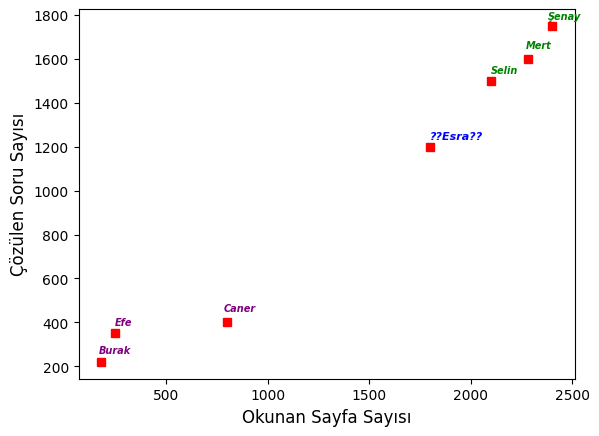

In [1]:
#Liste 12.1
import matplotlib.pyplot as plt
plt.axis('auto')

plt.xlabel("Okunan Sayfa Sayısı",fontsize=12,fontname='Cambria')
plt.ylabel("Çözülen Soru Sayısı",fontsize=12,fontname='Cambria')
x = [ 2100,2280,800,2400,250,180,1800]
y = [ 1500,1600,400,1750,350,220,1200]
plt.text(2382,1780,"Şenay",color='Green',style='italic',
             weight='bold', size='7')
plt.text(2269,1649,"Mert",color='Green',style='italic',
             weight='bold', size='7')
plt.text(2100,1535,"Selin",color='Green',style='italic',
             weight='bold', size='7')
plt.text(1800,1233,"??Esra??",color='Blue',style='italic',
             weight='bold', size='8')
plt.text(246,387,"Efe",color='Purple',style='italic',
             weight='bold', size='7')
plt.text(167,259,"Burak",color='Purple',style='italic',
             weight='bold', size='7')
plt.text(782,451,"Caner",color='Purple',style='italic',
             weight='bold', size='7')

plt.plot(x,y,'sr')

In [3]:
#Liste 12.2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

from google.colab import drive
drive.mount('/content/drive')
%cd /content/drive/MyDrive/
veriseti = pd.read_excel('Hafta11_Immunotherapy1.xlsx')
print(veriseti.head(15))

Mounted at /content/drive
/content/drive/MyDrive
    cinsiyet  yas   sure  adet  tip  alan  sertlesmeCapi  tedaviSonuc
0          1   22   2.25    14    3    51             50            1
1          1   15   3.00     2    3   900             70            1
2          2   28   7.50     4    1     9              2            1
3          2   19   6.00     2    1   225              8            1
4          2   32  12.00     6    3    35              5            0
5          2   33   6.25     2    1    30              3            1
6          2   17   5.75    12    3    25              7            1
7          2   15   1.75     1    2    49              7            0
8          2   15   5.50    12    1    48              7            1
9          2   16  10.00     7    1   143              6            1
10         2   33   9.25     2    2   150              8            1
11         2   19   2.25     2    1    60              7            1
12         2   26  10.50     6    1    50

In [4]:
#Liste 12.3
import re
kayip_veriler = []
sayisal_olmayan_veriler = []

for ozellik in veriseti:
    # Tüm eşsiz özellik  değerleri
    essiz_deger = veriseti[ozellik].unique()
    print ("'{}' özelliğine ait essiz(unique) veri sayısı: {}" .format(ozellik,essiz_deger.size))
    if (essiz_deger.size > 10):
        print("10 adet benzersiz değer listele")
    print (essiz_deger[0:10])
    print ("\n-----------------------------------------------------------------------\n")

    # Özelliklere ait kayıp verileri bul
    if (True in pd.isnull(essiz_deger)):
        s = "{} özeliğine ait kayı veri sayısı: {} " .format(ozellik, pd.isnull(veriseti[ozellik]).sum())
        kayip_veriler.append(s)

    # Özelliklere ait sayısal olayan verileri bul
    for i in range (1, np.prod(essiz_deger.shape)):
        if (re.match('nan', str(essiz_deger[i]))):
            break
        if not (re.search('(^\d+\.?\d*$)|(^\d*\.?\d+$)', str(essiz_deger[i]))):
            sayisal_olmayan_veriler.append(ozellik)
            break

print ("Kayıp veriye sahip özellikler:\n{}\n\n" .format(kayip_veriler))
print ("Sayısal olmayan veriye sahip özellikler:\n{}" .format(sayisal_olmayan_veriler))

'cinsiyet' özelliğine ait essiz(unique) veri sayısı: 2
[1 2]

-----------------------------------------------------------------------

'yas' özelliğine ait essiz(unique) veri sayısı: 32
10 adet benzersiz değer listele
[22 15 28 19 32 33 17 16 26 25]

-----------------------------------------------------------------------

'sure' özelliğine ait essiz(unique) veri sayısı: 32
10 adet benzersiz değer listele
[ 2.25  3.    7.5   6.   12.    6.25  5.75  1.75  5.5  10.  ]

-----------------------------------------------------------------------

'adet' özelliğine ait essiz(unique) veri sayısı: 15
10 adet benzersiz değer listele
[14  2  4  6 12  1  7 10 18 11]

-----------------------------------------------------------------------

'tip' özelliğine ait essiz(unique) veri sayısı: 3
[3 1 2]

-----------------------------------------------------------------------

'alan' özelliğine ait essiz(unique) veri sayısı: 54
10 adet benzersiz değer listele
[ 51 900   9 225  35  30  25  49  48 143]

-------

<>:24: SyntaxWarning: invalid escape sequence '\d'
<>:24: SyntaxWarning: invalid escape sequence '\d'
/tmp/ipython-input-3101717235.py:24: SyntaxWarning: invalid escape sequence '\d'
  if not (re.search('(^\d+\.?\d*$)|(^\d*\.?\d+$)', str(essiz_deger[i]))):


In [5]:
#Liste 12.4
X = veriseti.iloc[:, :-1].values
y = veriseti.iloc[:, -1].values
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.25, random_state = 0)
#Özellik ölçeklendirme İşlemi
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.fit_transform(X_test)
y_train=scaler.fit_transform(y_train.reshape(-1,1))
y_test=scaler.fit_transform(y_test.reshape(-1,1))

In [6]:
#Liste 12.5
from sklearn.neighbors import KNeighborsClassifier
siniflandirici = KNeighborsClassifier(n_neighbors = 5, metric = 'minkowski', p = 2)
siniflandirici.fit(X_train, y_train)
# Test seti sonuçlarının tahmin edilmesi
y_pred = siniflandirici.predict(X_test)

/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_classification.py:239: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [7]:
#Liste 12.6
from sklearn.metrics import confusion_matrix,classification_report
hm = confusion_matrix(y_test, y_pred)

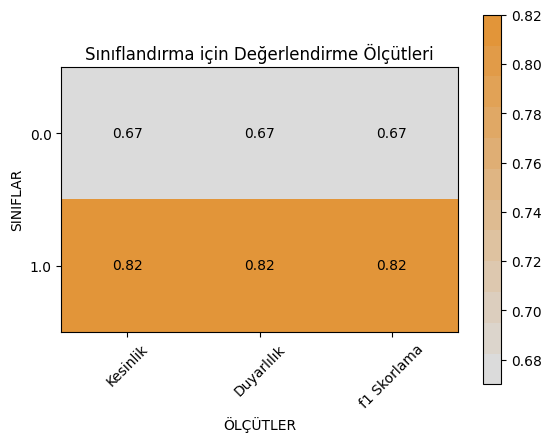

In [8]:
#Liste 12.7
#Sınıflandırma Raporu grafiği
from matplotlib import colors
from matplotlib.colors import ListedColormap
renkler = ['#DBDBDB','#DCD5CC','#DCCEBE','#DDC8AF','#DEC2A0','#DEBB91',\
            '#DFB583','#DFAE74','#E0A865','#E1A256','#E19B48','#E29539']
renkler2 = colors.ListedColormap(renkler)

def degerlendirmeOlcutleri(rapor, title=None, cmap=renkler2):

    satirlar = rapor.split('\n')
    sinifEtiketleri = []
    liste = []

    for i in satirlar[2:(len(satirlar)-5)]:
        s = i.split()
        sinifEtiketleri.append(s[0])
        deger = [float(x) for x in s[1: len(s) - 1]]
        liste.append(deger)

    fig, ax = plt.subplots(1)

    for sutun in range(len(liste)+1):
        for satir in range(len(sinifEtiketleri)):
            txt = liste[satir][sutun]
            ax.text(sutun,satir,liste[satir][sutun],va='center',ha='center')

    fig = plt.imshow(liste, interpolation='nearest', cmap=cmap)
    plt.title('Sınıflandırma için Değerlendirme Ölçütleri')
    plt.colorbar()
    x_ticks = np.arange(len(sinifEtiketleri)+1)
    y_ticks = np.arange(len(sinifEtiketleri))
    plt.xticks(x_ticks, ['Kesinlik', 'Duyarlılık', 'f1 Skorlama'], rotation=45)
    plt.yticks(y_ticks, sinifEtiketleri)
    plt.ylabel('SINIFLAR')
    plt.xlabel('ÖLÇÜTLER')
    plt.show()

rapor = classification_report(y_test, y_pred)
degerlendirmeOlcutleri(rapor)

In [9]:
#Liste 12.8
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

         0.0       0.67      0.67      0.67         6
         1.0       0.82      0.82      0.82        11

    accuracy                           0.76        17
   macro avg       0.74      0.74      0.74        17
weighted avg       0.76      0.76      0.76        17



/tmp/ipython-input-731588888.py:12: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "m." (-> color='m'). The keyword argument will take precedence.
  plt.plot(range(1,31), hatalarListesi,'m.', color='blue', linestyle='--', markersize=6)


Text(0, 0.5, 'Hata oranı')

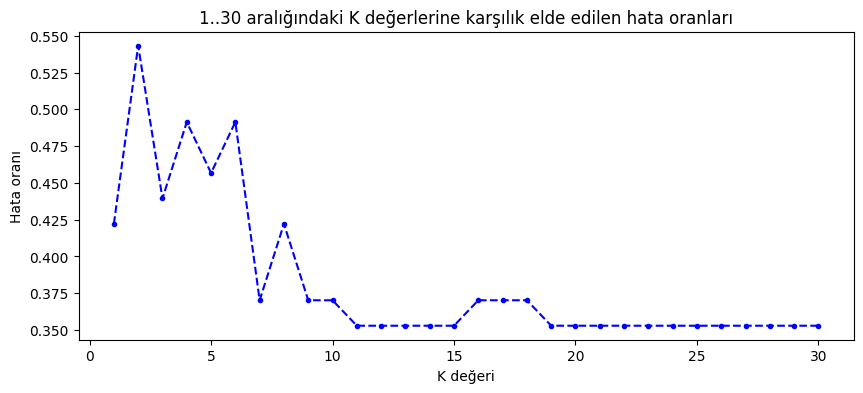

In [10]:
#Liste 12.9
hatalarListesi = []
for i in range(1,31):

    siniflandirici = KNeighborsClassifier(n_neighbors=i)
    siniflandirici.fit(X_train, np.ravel(y_train))
    pred_i = siniflandirici.predict(X_test)
    hatalarListesi.append(np.mean(pred_i != y_test))

# k değerlerine karşılık hata oranlarını veren grafiğin çizilmesi
plt.figure(figsize=(10,4))
plt.plot(range(1,31), hatalarListesi,'m.', color='blue', linestyle='--', markersize=6)
plt.title('1..30 aralığındaki K değerlerine karşılık elde edilen hata oranları')
plt.xlabel('K değeri')
plt.ylabel('Hata oranı')



              precision    recall  f1-score   support

         0.0       0.25      0.17      0.20         6
         1.0       0.62      0.73      0.67        11

    accuracy                           0.53        17
   macro avg       0.43      0.45      0.43        17
weighted avg       0.49      0.53      0.50        17



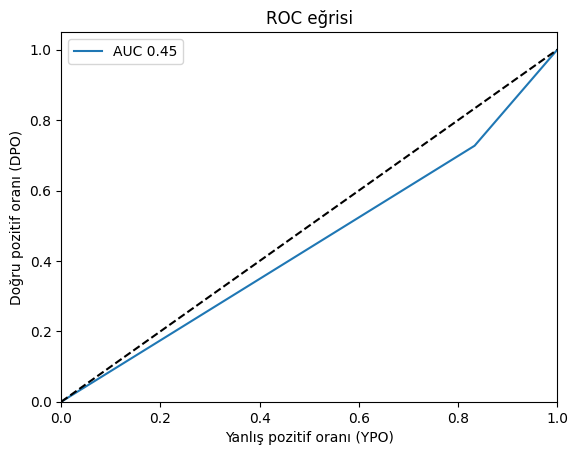

In [11]:
#Liste 12.10
#yeni en uygun k değeri ile (az gürültülü) model tekrar eğitiliyor
from sklearn.neighbors import KNeighborsClassifier
siniflandirici = KNeighborsClassifier(n_neighbors = 8, metric = 'minkowski', p = 2)
siniflandirici.fit(X_train, np.ravel(y_train))
y_pred = siniflandirici.predict(X_test)
from sklearn.metrics import confusion_matrix,classification_report
hm = confusion_matrix(y_test, y_pred)
print(classification_report(y_test, y_pred))

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc
ypo, dpo, esikDeger = roc_curve(y_test, y_pred)
aucDegeri = auc(ypo, dpo)

plt.figure()
plt.plot(ypo, dpo, label='AUC %0.2f' % aucDegeri)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Yanlış pozitif oranı (YPO)')
plt.ylabel('Doğru pozitif oranı (DPO)')
plt.title('ROC eğrisi')
plt.legend(loc="best")
plt.show()

In [12]:
#Liste 12.10
#Yeni veri için tahmin sonuçları
_cinsiyet=2
_yas=26
_sure=11
_adet=6
_tip=1
_alan=50
_sertlesmeCapi=9

girdiler = np.array([_cinsiyet, _yas, _sure, _adet,_tip,_alan,_sertlesmeCapi])
girdiler=scaler.fit_transform(girdiler.reshape(1,-1))
y_pred2 = siniflandirici.predict(np.reshape(girdiler, (1, -1)))
print(y_pred2)

[1.]
